In [1]:
from google.colab import files
uploaded = files.upload()

Saving insurance.csv to insurance.csv


Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Load Dataset

In [3]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Dataset Information

In [4]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Statistical Summary:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.29625

Encode Categorical Columns

In [5]:
encoder = LabelEncoder()

df['sex'] = encoder.fit_transform(df['sex'])
df['smoker'] = encoder.fit_transform(df['smoker'])
df['region'] = encoder.fit_transform(df['region'])

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


Select Features and Target

In [6]:
X = df.drop("charges", axis=1)
y = df["charges"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   age  sex     bmi  children  smoker  region
0   19    0  27.900         0       1       3
1   18    1  33.770         1       0       2
2   28    1  33.000         3       0       2
3   33    1  22.705         0       0       1
4   32    1  28.880         0       0       1

Target:
0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64


Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 1070
Testing Samples: 268


Train the Model

In [8]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


Predictions

In [9]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,9095.06825,8924.407244
1,5272.17580,7116.295018
2,29330.98315,36909.013521
3,9301.89355,9507.874691
4,33750.29180,27013.350008
5,4536.25900,10790.779562
6,2117.33885,226.298446
7,14210.53595,16942.715999
8,3732.62510,1056.630794
9,10264.44210,11267.919973


Regression Line (BMI vs Charges)

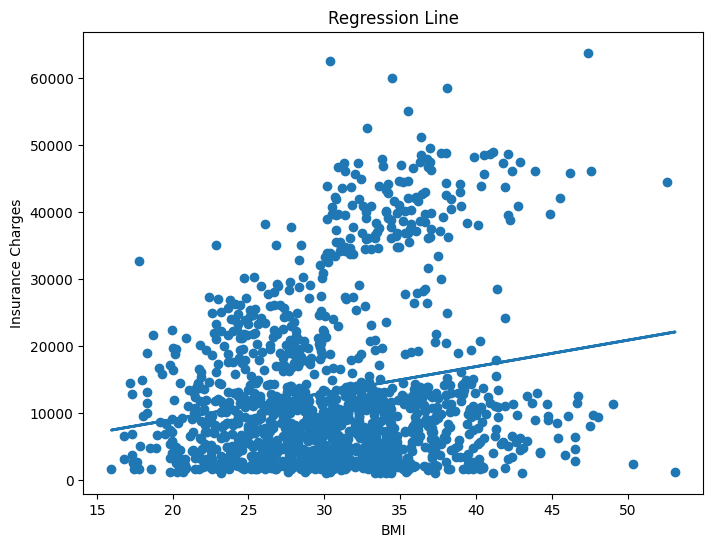

In [10]:
X_single = df[['bmi']]
y_single = df['charges']

single_model = LinearRegression()
single_model.fit(X_single, y_single)

plt.figure(figsize=(8,6))

plt.scatter(X_single, y_single)

plt.plot(
    X_single,
    single_model.predict(X_single),
    linewidth=2
)

plt.xlabel("BMI")
plt.ylabel("Insurance Charges")
plt.title("Regression Line")

plt.show()

Slope, Intercept and Equation

In [11]:
print("Slope (BMI):", single_model.coef_[0])

print("Intercept:", single_model.intercept_)

print("\nEquation:")

print(f"Charges = {single_model.coef_[0]:.2f} × BMI + {single_model.intercept_:.2f}")

Slope (BMI): 393.87303079739524
Intercept: 1192.9372089611497

Equation:
Charges = 393.87 × BMI + 1192.94


MAE, MSE and R² Score

In [12]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 4186.508898366433
Mean Squared Error (MSE): 33635210.431178406
R² Score: 0.7833463107364539


Predict 3 New Values

In [13]:
  new_customers = pd.DataFrame({
    "age":[25,40,55],
    "sex":[1,0,1],          # Male=1, Female=0
    "bmi":[24.5,31.2,28.7],
    "children":[0,2,3],
    "smoker":[0,1,0],       # No=0, Yes=1
    "region":[2,1,3]
})

predictions = model.predict(new_customers)

new_customers["Predicted Charges"] = predictions

new_customers

,age,sex,bmi,children,smoker,region,Predicted Charges
0,25,1,24.5,0,0,2,2145.086564
1,40,0,31.2,2,1,1,33038.743240
2,55,1,28.7,3,0,3,12271.046838


Model Performance

In [14]:
print("Model Performance Evaluation\n")

print("MAE :", mae)
print("MSE :", mse)
print("R² :", r2)

if r2 >= 0.90:
    print("\nPerformance : Best")
    print("Reason : The model explains more than 90% of the variance in the data.")

elif r2 >= 0.75:
    print("\nPerformance : Good")
    print("Reason : The model predicts insurance charges with good accuracy and a high R² score.")

else:
    print("\nPerformance : Needs Improvement")
    print("Reason : The model does not explain enough variance and prediction errors are comparatively high.")

Model Performance Evaluation

MAE : 4186.508898366433
MSE : 33635210.431178406
R² : 0.7833463107364539

Performance : Good
Reason : The model predicts insurance charges with good accuracy and a high R² score.
